# Tech Challenge — Fase 3
## Predição e Inteligência Analítica para Alfabetização no Brasil

### Notebook baseado exclusivamente na camada Gold da Fase 2

O modelo principal procura responder, com os dados disponíveis na Gold:

- quais municípios apresentam maior risco educacional;
- quais variáveis estão mais associadas ao atingimento da meta;
- quais municípios/regiões possuem padrões semelhantes;
- como apoiar a priorização de políticas públicas;
- quando houver histórico temporal suficiente, como usar informações de um ano para prever o atingimento da meta no ano seguinte.

> **Importante:** nenhuma variável derivada diretamente do resultado do mesmo período é utilizada como feature do modelo, evitando data leakage.

## 1. Aderência ao enunciado

O Tech Challenge exige:

1. utilização da camada Gold da Fase 2;
2. análise exploratória;
3. pipeline completa de Machine Learning;
4. imputação e transformação de variáveis;
5. prevenção de data leakage;
6. separação treino/teste e validação;
7. otimização/generalização;
8. Feature Importance e SHAP;
9. aplicação estratégica para municípios e políticas públicas;
10. documentação das limitações e possíveis evoluções.

Este notebook distingue claramente:

- **objetivo conceitual do desafio:** alfabetização;
- **unidade observacional disponível na Gold:** município/ano;
- **target executável com a Gold:** atingimento da meta;
- **não permitido:** inventar registros individuais a partir de agregados municipais.

Essa decisão privilegia rastreabilidade, validade estatística e reprodutibilidade.

In [1]:

# ============================================================
# 2. Configuração e imports
# ============================================================
from pathlib import Path
import json
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from joblib import dump

warnings.filterwarnings("ignore")

SEED = 42
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
GOLD_DIR = DATA_DIR / "gold"
REPORTS = ROOT / "reports"
FIGURES = ROOT / "images"
MODELS = ROOT / "models"

for p in [REPORTS, FIGURES, MODELS]:
    p.mkdir(parents=True, exist_ok=True)

print("Diretório de execução:", ROOT)
print("Gold:", GOLD_DIR)


Diretório de execução: f:\FIAP\TechChallenge-Fase3
Gold: f:\FIAP\TechChallenge-Fase3\data\gold


## 3. Descoberta e auditoria da Gold

O notebook procura automaticamente os arquivos Parquet/CSV da camada `data/gold`. A escolha é baseada no conteúdo e nos nomes das tabelas, priorizando a Gold analítica municipal.

In [2]:
# ============================================================
# 3. Descoberta e composição da Gold
# ============================================================
def read_table(path):
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path, sep=None, engine="python")

def normalize_col(c):
    c = str(c).strip().lower()
    repl = {
        "ç":"c","ã":"a","á":"a","à":"a","â":"a","ä":"a",
        "é":"e","ê":"e","í":"i","ó":"o","ô":"o","õ":"o","ú":"u"
    }
    for a,b in repl.items():
        c = c.replace(a,b)
    return re.sub(r"[^a-z0-9]+", "_", c).strip("_")

files = sorted(list(GOLD_DIR.rglob("*.parquet")) + list(GOLD_DIR.rglob("*.csv")))

if not files:
    raise FileNotFoundError("Nenhum arquivo foi encontrado em data/gold.")

inventory = []
tables = {}

for f in files:
    try:
        tmp = read_table(f).copy()
        tmp.columns = [normalize_col(c) for c in tmp.columns]
        tables[str(f)] = tmp

        cols = list(tmp.columns)
        score = 0
        for term, pts in [
            ("resultado_alfabetizacao", 12),
            ("target_atingiu_meta", 12),
            ("meta_alfabetizacao", 8),
            ("gap_meta", 8),
            ("municipio", 6),
            ("uf", 3),
            ("populacao", 3),
            ("socio", 2),
            ("risco", 2),
            ("ano", 2),
        ]:
            if any(term in c for c in cols):
                score += pts

        inventory.append({
            "arquivo": str(f),
            "linhas": len(tmp),
            "colunas": len(tmp.columns),
            "score": score
        })
    except Exception as exc:
        inventory.append({
            "arquivo": str(f),
            "linhas": None,
            "colunas": None,
            "score": -999,
            "erro": str(exc)
        })

inventory_df = pd.DataFrame(inventory).sort_values(
    ["score", "linhas"], ascending=[False, False]
)
display(inventory_df)

# Identificação de chaves comuns.
all_cols = sorted(set().union(*[set(t.columns) for t in tables.values()]))

def first_in(df, patterns):
    for p in patterns:
        hits = [c for c in df.columns if re.search(p, c, re.I)]
        if hits:
            return hits[0]
    return None

def choose_key_pair(left, right):
    candidates = [
        ("id_municipio", "id_municipio"),
        ("codigo_municipio", "codigo_municipio"),
        ("cod_municipio", "cod_municipio"),
        ("municipio_id", "municipio_id"),
        ("uf", "uf"),
    ]
    for a,b in candidates:
        if a in left.columns and b in right.columns:
            return a,b
    return None

# Começa pela tabela Gold com melhor score e tenta enriquecer com as demais
# somente quando existe uma chave de junção segura.
base_path = Path(inventory_df.iloc[0]["arquivo"])
df = tables[str(base_path)].copy()

for other_path, other in tables.items():
    if other_path == str(base_path):
        continue

    # evita joins quando não há chave municipal/ano comum
    common = set(df.columns).intersection(other.columns)
    keys = [k for k in ["id_municipio","codigo_municipio","cod_municipio","municipio_id"] if k in common]

    if not keys:
        continue

    join_keys = keys.copy()
    if "ano" in common:
        join_keys.append("ano")

    # Só agrega tabela externa se a combinação de chaves for suficientemente única.
    right = other.copy()
    if right.duplicated(join_keys).any():
        agg_cols = [c for c in right.columns if c not in join_keys]
        num_cols = [c for c in agg_cols if pd.api.types.is_numeric_dtype(right[c])]
        cat_cols = [c for c in agg_cols if not pd.api.types.is_numeric_dtype(right[c])]

        agg_map = {c:"mean" for c in num_cols}
        agg_map.update({c:"first" for c in cat_cols[:20]})
        if agg_map:
            right = right.groupby(join_keys, as_index=False).agg(agg_map)

    new_cols = [c for c in right.columns if c not in df.columns or c in join_keys]
    right = right[join_keys + [c for c in new_cols if c not in join_keys]]

    if len(right.columns) > len(join_keys):
        df = df.merge(right, on=join_keys, how="left", suffixes=("", "_enriched"))

# Remove colunas duplicadas criadas por joins.
df = df.loc[:, ~df.columns.duplicated()].copy()

print("Tabelas Gold disponíveis:", len(tables))
print("Tabela base:", base_path.name)
print("Dimensões finais após enriquecimento:", df.shape)
print("Colunas:", df.columns.tolist())

,arquivo,linhas,colunas,score
1,f:\FIAP\TechChallenge-Fase3\data\gold\gold_dat...,23995,10,50
0,f:\FIAP\TechChallenge-Fase3\data\gold\gold_com...,23995,10,38
2,f:\FIAP\TechChallenge-Fase3\data\gold\gold_ind...,23995,28,38
3,f:\FIAP\TechChallenge-Fase3\data\gold\gold_ind...,145,41,33


Tabelas Gold disponíveis: 4
Tabela base: gold_dataset_ia_municipio.parquet
Dimensões finais após enriquecimento: (23995, 29)
Colunas: ['ano', 'id_municipio', 'rede', 'serie', 'resultado_alfabetizacao', 'meta_alfabetizacao', 'gap_meta', 'status_meta', 'classificacao_risco', 'target_atingiu_meta', 'ano_meta', 'taxa_alfabetizacao', 'media_portugues', 'proporcao_aluno_nivel_0', 'proporcao_aluno_nivel_1', 'proporcao_aluno_nivel_2', 'proporcao_aluno_nivel_3', 'proporcao_aluno_nivel_4', 'proporcao_aluno_nivel_5', 'proporcao_aluno_nivel_6', 'proporcao_aluno_nivel_7', 'proporcao_aluno_nivel_8', 'taxa_alfabetizacao_meta_base', 'data_ingestao', 'origem', 'data_processamento', 'camada_origem', 'status_validacao', 'data_processamento_gold']


## 4. Perfil da base e identificação das variáveis

As colunas são normalizadas apenas para facilitar a automação. Os dados originais permanecem como fonte da análise.

In [3]:
# ============================================================
# 4. Perfil da base e identificação das variáveis
# ============================================================
def normalize_col(c):
    c = str(c).strip().lower()
    c = c.replace("ç", "c").replace("ã", "a").replace("á", "a").replace("é", "e")
    c = c.replace("í", "i").replace("ó", "o").replace("ú", "u")
    return re.sub(r"[^a-z0-9]+", "_", c).strip("_")

df.columns = [normalize_col(c) for c in df.columns]

def first_match(patterns, columns=None):
    columns = list(columns if columns is not None else df.columns)
    for pattern in patterns:
        hits = [c for c in columns if re.search(pattern, c, flags=re.I)]
        if hits:
            return hits[0]
    return None

municipality_col = first_match([
    r"^id_municipio$", r"^codigo_municipio$", r"^cod_municipio$",
    r"municipio", r"nome_municipio"
])
uf_col = first_match([r"^uf$", r"sigla_uf", r"estado"])
year_col = first_match([r"^ano$", r"ano_referencia", r"ano_ref", r"ano_base", r"year"])
result_col = first_match([
    r"^resultado_alfabetizacao$", r"resultado.*alfabet",
    r"taxa.*alfabet", r"percentual.*alfabet"
])
target_col = first_match([
    r"^target_atingiu_meta$", r"atingiu_meta", r"ating.*meta"
])
meta_col = first_match([r"meta_alfabetizacao", r"meta.*alfabet"])
gap_col = first_match([r"^gap_meta$", r"gap.*meta"])
risk_col = first_match([r"classificacao_risco", r"risco"])
population_col = first_match([r"populacao", r"populacao_total", r"pop_"])

identified = {
    "municipio": municipality_col,
    "uf": uf_col,
    "ano": year_col,
    "resultado": result_col,
    "target": target_col,
    "meta": meta_col,
    "gap": gap_col,
    "risco": risk_col,
    "populacao": population_col,
}
print(json.dumps(identified, ensure_ascii=False, indent=2))

audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unicos": df.nunique(dropna=True)
}).sort_values("missing_pct", ascending=False)

display(audit)


{
  "municipio": "id_municipio",
  "uf": null,
  "ano": "ano",
  "resultado": "resultado_alfabetizacao",
  "target": "target_atingiu_meta",
  "meta": "meta_alfabetizacao",
  "gap": "gap_meta",
  "risco": "classificacao_risco",
  "populacao": null
}


,dtype,missing,missing_pct,unicos
meta_alfabetizacao,float64,18763,78.20,2745
gap_meta,float64,18763,78.20,4077
target_atingiu_meta,float64,18763,78.20,2
taxa_alfabetizacao_meta_base,float64,12224,50.94,2591
proporcao_aluno_nivel_8,float64,11547,48.12,1794
proporcao_aluno_nivel_3,float64,11547,48.12,2733
proporcao_aluno_nivel_6,float64,11547,48.12,3166
proporcao_aluno_nivel_5,float64,11547,48.12,3259
proporcao_aluno_nivel_4,float64,11547,48.12,2971
proporcao_aluno_nivel_1,float64,11547,48.12,1849


## 5. Definição do target sem vazamento

### Estratégia prioritária: previsão temporal

Se a Gold possuir histórico de pelo menos dois anos por município, o notebook cria:

**`target_futuro = 1`** quando o município atinge a meta no próximo período e **`0`** quando não atinge.

As features são construídas a partir do período atual, permitindo uma interpretação de previsão.

Quando não existe histórico temporal suficiente, o notebook utiliza `target_atingiu_meta` da própria Gold como target municipal, deixando a limitação explícita.

Não são utilizadas como features as variáveis diretamente derivadas do resultado do período previsto, como `resultado_alfabetizacao`, `meta_alfabetizacao`, `gap_meta`, `status_meta`, `classificacao_risco` e o próprio target.

In [4]:
# ============================================================
# 5. Definição do target sem vazamento
# ============================================================

work = df.copy()

if target_col is None:
    raise ValueError(
        "A Gold selecionada não possui target_atingiu_meta/atingiu_meta. "
        "É necessário definir explicitamente um target compatível com a Gold."
    )

work[target_col] = pd.to_numeric(work[target_col], errors="coerce")
work = work.dropna(subset=[target_col]).copy()
work[target_col] = work[target_col].astype(int)

use_future_target = False
future_target_col = "target_futuro"

if municipality_col and year_col:
    work[year_col] = pd.to_numeric(work[year_col], errors="coerce")
    valid_years = work[year_col].dropna().nunique()
    repeated_municipal_years = (
        work.dropna(subset=[municipality_col, year_col])
            .groupby(municipality_col)[year_col]
            .nunique()
    )
    if valid_years >= 2 and (repeated_municipal_years >= 2).mean() >= 0.50:
        ordered = work.sort_values([municipality_col, year_col]).copy()
        ordered[future_target_col] = ordered.groupby(municipality_col)[target_col].shift(-1)
        ordered["ano_alvo"] = ordered.groupby(municipality_col)[year_col].shift(-1)
        ordered = ordered.dropna(subset=[future_target_col]).copy()
        ordered[future_target_col] = ordered[future_target_col].astype(int)
        work = ordered
        TARGET = future_target_col
        use_future_target = True
    else:
        TARGET = target_col
else:
    TARGET = target_col

print("Target utilizado:", TARGET)
print("Estratégia temporal:", use_future_target)
print("Distribuição:")
display(work[TARGET].value_counts(dropna=False).rename("quantidade").to_frame())
display((work[TARGET].value_counts(normalize=True) * 100).round(2).rename("%").to_frame())


Target utilizado: target_atingiu_meta
Estratégia temporal: False
Distribuição:


,quantidade
target_atingiu_meta,
1,2788
0,2444


,%
target_atingiu_meta,
1,53.29
0,46.71


## 6. EDA — comportamento, distribuição e hipóteses

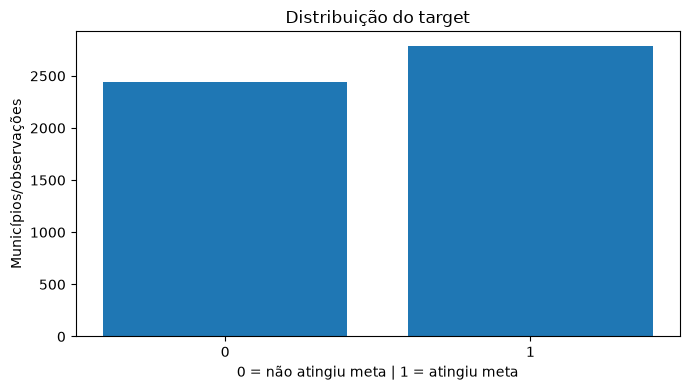

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ano,5232.0,<NA>,<NA>,<NA>,2024.0,2024.0,2024.0,2024.0,2024.0,2024.0,0.0
id_municipio,5232,5232,3532868,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rede,5232,1,municipal,5232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
serie,5232.0,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,2.0,0.0
resultado_alfabetizacao,5232.0,NaN,NaN,NaN,63.266586,6.25,48.98,64.46,77.79,100.0,19.153987
meta_alfabetizacao,5232.0,NaN,NaN,NaN,62.151745,7.94,52.17,64.095,75.885,80.0,15.098183
gap_meta,5232.0,NaN,NaN,NaN,1.114841,-68.9,-7.74,0.98,10.8125,84.27,15.201525
status_meta,5232,2,atingiu_meta,2788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classificacao_risco,5232,4,baixo_risco,2788,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_atingiu_meta,5232.0,NaN,NaN,NaN,0.532875,0.0,0.0,1.0,1.0,1.0,0.498966


In [5]:
# ============================================================
# 6. EDA — comportamento, distribuição e hipóteses
# ============================================================
# Distribuição do target
counts = work[TARGET].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribuição do target")
plt.xlabel("0 = não atingiu meta | 1 = atingiu meta")
plt.ylabel("Municípios/observações")
plt.tight_layout()
plt.savefig(FIGURES / "01_distribuicao_target.png", dpi=160, bbox_inches="tight")
plt.show()

""" # Missing values
missing = (
    work.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .head(20)
)
plt.figure(figsize=(9,5))
plt.barh(missing.index[::-1], missing.values[::-1])
plt.title("Top 20 variáveis com maior percentual de missing")
plt.xlabel("% missing")
plt.tight_layout()
plt.savefig(FIGURES / "02_missing.png", dpi=160, bbox_inches="tight")
plt.show() """

# Descritiva numérica
display(work.describe(include="all").T.head(50))


gap_meta                        0.763656
resultado_alfabetizacao         0.567171
taxa_alfabetizacao              0.559233
media_portugues                 0.507807
proporcao_aluno_nivel_3         0.454922
proporcao_aluno_nivel_6         0.436363
proporcao_aluno_nivel_2         0.431875
proporcao_aluno_nivel_4         0.408113
proporcao_aluno_nivel_7         0.385099
proporcao_aluno_nivel_1         0.368727
taxa_alfabetizacao_meta_base    0.272517
proporcao_aluno_nivel_8         0.269418
proporcao_aluno_nivel_0         0.266026
proporcao_aluno_nivel_5         0.164213
meta_alfabetizacao              0.049354
ano                                  NaN
serie                                NaN
ano_meta                             NaN
Name: correlacao_abs, dtype: float64

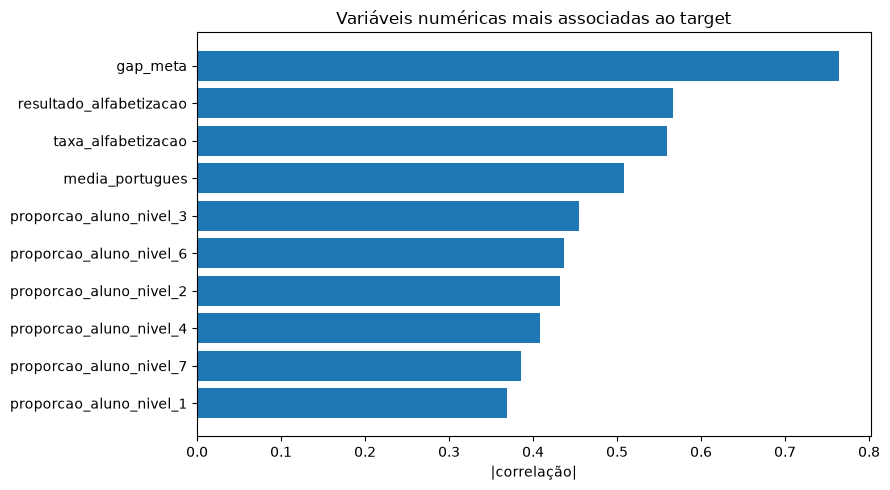

,count,mean,median,std
target,,,,
0,2444,51.664738,52.020,15.361848
1,2788,73.436930,75.965,16.131645


In [6]:

# Relações exploratórias de indicadores numéricos com o target.
numeric_all = work.select_dtypes(include=np.number).columns.tolist()
corr_target = (
    work[numeric_all]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET, errors="ignore")
    .abs()
    .sort_values(ascending=False)
)

display(corr_target.head(20).rename("correlacao_abs"))

top_corr = corr_target.head(10)
if len(top_corr):
    plt.figure(figsize=(9,5))
    plt.barh(top_corr.index[::-1], top_corr.values[::-1])
    plt.title("Variáveis numéricas mais associadas ao target")
    plt.xlabel("|correlação|")
    plt.tight_layout()
    plt.savefig(FIGURES / "03_correlacoes_target.png", dpi=160, bbox_inches="tight")
    plt.show()

# Relação entre resultado e target apenas para diagnóstico, nunca como feature.
if result_col and result_col in work.columns:
    result_numeric = pd.to_numeric(work[result_col], errors="coerce")
    diagnostic = pd.DataFrame({"resultado": result_numeric, "target": work[TARGET]}).dropna()
    if not diagnostic.empty:
        display(diagnostic.groupby("target")["resultado"].agg(["count","mean","median","std"]))


## 7. Prevenção de data leakage

São excluídas:

- a variável-alvo;
- `resultado_alfabetizacao`;
- `meta_alfabetizacao`;
- `gap_meta`;
- `status_meta`;
- `classificacao_risco`;
- qualquer coluna que represente diretamente o resultado final;
- IDs técnicos e chaves de relacionamento, mantidos para joins e relatórios, mas não usados como preditores;
- IDs técnicos e chaves de identificação;
- `target_atingiu_meta` quando ele não for o target;
- `ano_alvo`, criado apenas para controle da previsão futura.

Variáveis de contexto territorial, socioeconômico e educacional permanecem disponíveis quando não representam o resultado que está sendo previsto.

In [7]:
# ============================================================
# 7. Prevenção de data leakage
# ============================================================
LEAK_EXACT = {
    "resultado_alfabetizacao",
    "meta_alfabetizacao",
    "gap_meta",
    "status_meta",
    "classificacao_risco",
    "target_atingiu_meta",
    "target_futuro",
    "ano_alvo",
}

# Padrões fortes: somente termos que identificam resultado/proficiência/target.
LEAK_STRONG_PATTERNS = [
    r"^target($|_)",
    r"^label($|_)",
    r"^y($|_)",
    r"^profici",
    r"^score(_|$)",
    r"^nota(_|$)",
    r"^resultado_alfabet",
    r"^meta_alfabet",
    r"^gap_meta",
    r"status_meta",
    r"classificacao_risco",
]

ID_EXACT = {
    "id_aluno", "id_estudante", "matricula",
}

ID_PATTERNS = [
    r"^id_escola$",
    r"^id_municipio$",
    r"^codigo_municipio$",
    r"^cod_municipio$",
    r"^codigo_uf$",
    r"^id_uf$",
]

drop_cols = set()

for c in work.columns:
    if c == TARGET:
        continue

    lc = c.lower()

    if lc in LEAK_EXACT:
        drop_cols.add(c)
        continue

    if any(re.search(p, lc, re.I) for p in LEAK_STRONG_PATTERNS):
        drop_cols.add(c)
        continue

    # IDs podem ser usados para join/relatório, mas não devem entrar no modelo.
    if lc in ID_EXACT or any(re.search(p, lc, re.I) for p in ID_PATTERNS):
        drop_cols.add(c)

# Não remover genericamente "resultado", "risco" ou "meta":
# somente os campos conhecidos como derivados do alvo.
# Remove constantes.
work_model = work.drop(columns=sorted(drop_cols), errors="ignore").copy()

constant_cols = [
    c for c in work_model.columns
    if c != TARGET and work_model[c].nunique(dropna=True) <= 1
]
work_model = work_model.drop(columns=constant_cols, errors="ignore")
drop_cols.update(constant_cols)

X = work_model.drop(columns=[TARGET], errors="ignore")
y = work_model[TARGET].astype(int)

# Categóricas com cardinalidade extrema são tratadas como identificadores.
high_card = [
    c for c in X.select_dtypes(include=["object","category","bool"]).columns
    if X[c].nunique(dropna=True) > max(100, int(0.50 * len(X)))
]
X = X.drop(columns=high_card, errors="ignore")
drop_cols.update(high_card)

# Segurança: não permitir X vazio.
if X.shape[1] == 0:
    raise ValueError(
        "A Gold não possui nenhuma variável preditora após a remoção de "
        "target/leakage/IDs. Não é válido fabricar features. "
        "Verifique as Golds disponíveis ou adicione variáveis contextuais à camada Gold."
    )

print("Colunas removidas por leakage/IDs/constância/alta cardinalidade:")
print(sorted(drop_cols))
print("\\nFeatures finais:", X.shape[1])
print(X.dtypes.value_counts())
print("Target:", y.value_counts().to_dict())


Colunas removidas por leakage/IDs/constância/alta cardinalidade:
['ano', 'ano_meta', 'camada_origem', 'classificacao_risco', 'data_ingestao', 'data_processamento', 'data_processamento_gold', 'gap_meta', 'id_municipio', 'meta_alfabetizacao', 'origem', 'rede', 'resultado_alfabetizacao', 'serie', 'status_meta', 'status_validacao']
\nFeatures finais: 12
float64    12
Name: count, dtype: int64
Target: {1: 2788, 0: 2444}


## 8. Separação treino/teste

Quando o target é futuro, a divisão temporal é usada. Caso contrário, aplica-se divisão estratificada. O pré-processamento é ajustado exclusivamente dentro do pipeline.

In [8]:
# ============================================================
# 8. Separação treino/teste
# ============================================================
temporal_split = False

if use_future_target and year_col and year_col in X.columns:
    years = pd.to_numeric(X[year_col], errors="coerce")
    unique_years = sorted(years.dropna().unique())
    if len(unique_years) >= 2:
        last_year = unique_years[-1]
        train_mask = years < last_year
        test_mask = years == last_year
        if train_mask.sum() > 0 and test_mask.sum() > 0 and y.loc[train_mask].nunique() == 2 and y.loc[test_mask].nunique() == 2:
            X_train, X_test = X.loc[train_mask].copy(), X.loc[test_mask].copy()
            y_train, y_test = y.loc[train_mask].copy(), y.loc[test_mask].copy()
            temporal_split = True

if not temporal_split:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=SEED
    )

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object","category","bool"]).columns.tolist()

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features)
], remainder="drop")

print("Split temporal:", temporal_split)
print("Treino:", X_train.shape, y_train.value_counts().to_dict())
print("Teste:", X_test.shape, y_test.value_counts().to_dict())


Split temporal: False
Treino: (4185, 12) {1: 2230, 0: 1955}
Teste: (1047, 12) {1: 558, 0: 489}


## 9. Comparação de modelos

São comparados baseline, Regressão Logística, Random Forest e Extra Trees. A seleção considera F1 e PR-AUC, mantendo balanced accuracy e ROC-AUC como métricas complementares.

In [9]:
# ============================================================
# 9. Comparação de modelos
# ============================================================
# Diagnóstico final antes do treinamento
print("Dimensões X_train:", X_train.shape)
print("Dimensões X_test :", X_test.shape)
print("Quantidade de features:", X_train.shape[1])

if X_train.shape[1] == 0:
    raise ValueError(
        "X_train está vazio. O pipeline foi interrompido para evitar treinamento inválido."
    )


Dimensões X_train: (4185, 12)
Dimensões X_test : (1047, 12)
Quantidade de features: 12


In [10]:

models = {
    "baseline": Pipeline([
        ("prep", preprocessor),
        ("model", DummyClassifier(strategy="prior"))
    ]),
    "logistic_regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=SEED
        ))
    ]),
    "random_forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=400, min_samples_leaf=2,
            class_weight="balanced", random_state=SEED, n_jobs=-1
        ))
    ]),
    "extra_trees": Pipeline([
        ("prep", preprocessor),
        ("model", ExtraTreesClassifier(
            n_estimators=400, min_samples_leaf=2,
            class_weight="balanced", random_state=SEED, n_jobs=-1
        ))
    ])
}

n_splits = min(5, int(y_train.value_counts().min()))
if n_splits < 2:
    raise ValueError("Cada classe precisa ter pelo menos 2 observações no treino para validação cruzada.")
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

cv_rows = []
for name, pipe in models.items():
    result = cross_validate(
        pipe, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=1,
        error_score="raise"
    )
    row = {"modelo": name}
    for metric in scoring:
        row[f"{metric}_media"] = result[f"test_{metric}"].mean()
        row[f"{metric}_std"] = result[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(["f1_media","pr_auc_media"], ascending=False)
    .reset_index(drop=True)
)

display(cv_results)
cv_results.to_csv(REPORTS / "model_comparison_cv.csv", index=False)


,modelo,accuracy_media,accuracy_std,balanced_accuracy_media,balanced_accuracy_std,precision_media,precision_std,recall_media,recall_std,f1_media,f1_std,roc_auc_media,roc_auc_std,pr_auc_media,pr_auc_std
0,logistic_regression,0.811708,0.008767,0.812248,0.008481,0.836421,0.009379,0.804036,0.017575,0.819770,0.009695,0.896423,0.009301,0.915048,0.008006
1,random_forest,0.800239,0.013483,0.802495,0.013411,0.843116,0.014224,0.768161,0.017802,0.803795,0.013866,0.886081,0.011674,0.912862,0.007823
2,extra_trees,0.791398,0.010887,0.793631,0.011223,0.834367,0.015915,0.759641,0.012395,0.795131,0.010162,0.877763,0.013551,0.905665,0.010140
3,baseline,0.532855,0.000000,0.500000,0.000000,0.532855,0.000000,1.000000,0.000000,0.695246,0.000000,0.500000,0.000000,0.532855,0.000000


## 10. Otimização do melhor modelo

In [11]:
# ============================================================
# 10. Otimização do melhor modelo
# ============================================================
candidate_names = [m for m in cv_results["modelo"].tolist() if m != "baseline"]
best_name = candidate_names[0]
best_pipe = models[best_name]

if best_name == "logistic_regression":
    param_distributions = {
        "model__C": np.logspace(-2, 2, 12),
        "model__class_weight": [None, "balanced"]
    }
elif best_name in ["random_forest", "extra_trees"]:
    param_distributions = {
        "model__n_estimators": [300, 500, 700],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 5, 10],
        "model__max_features": ["sqrt", "log2", None]
    }
else:
    param_distributions = {}

if param_distributions:
    search = RandomizedSearchCV(
        best_pipe,
        param_distributions=param_distributions,
        n_iter=min(12, max(1, np.prod([len(v) for v in param_distributions.values()]))),
        scoring="f1",
        cv=cv,
        random_state=SEED,
        n_jobs=1
    )
    search.fit(X_train, y_train)
    champion = search.best_estimator_
    tuning = {
        "modelo_base": best_name,
        "best_params": search.best_params_,
        "best_cv_f1": float(search.best_score_)
    }
else:
    champion = best_pipe.fit(X_train, y_train)
    tuning = {"modelo_base": best_name, "best_params": {}}

print("Modelo campeão:", best_name)
print(json.dumps(tuning, ensure_ascii=False, indent=2))


Modelo campeão: logistic_regression
{
  "modelo_base": "logistic_regression",
  "best_params": {
    "model__class_weight": null,
    "model__C": 18.73817422860385
  },
  "best_cv_f1": 0.8262814070320175
}


## 11. Avaliação final no teste

In [12]:
# ============================================================
# 11. Avaliação final no teste
# ============================================================
champion.fit(X_train, y_train)

pred = champion.predict(X_test)
proba = champion.predict_proba(X_test)[:, 1]

metrics_final = {
    "accuracy": accuracy_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred, zero_division=0),
    "recall": recall_score(y_test, pred, zero_division=0),
    "f1": f1_score(y_test, pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba),
    "pr_auc": average_precision_score(y_test, proba),
}

metrics_df = pd.DataFrame({"valor": metrics_final})
display(metrics_df)

with open(REPORTS / "metrics_final.json", "w", encoding="utf-8") as f:
    json.dump(metrics_final, f, ensure_ascii=False, indent=2)

print(classification_report(y_test, pred, digits=4, zero_division=0))


,valor
accuracy,0.809933
balanced_accuracy,0.808282
precision,0.814361
recall,0.833333
f1,0.823738
roc_auc,0.898681
pr_auc,0.920527


              precision    recall  f1-score   support

           0     0.8046    0.7832    0.7938       489
           1     0.8144    0.8333    0.8237       558

    accuracy                         0.8099      1047
   macro avg     0.8095    0.8083    0.8088      1047
weighted avg     0.8098    0.8099    0.8097      1047



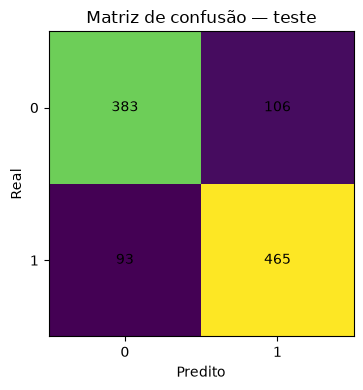

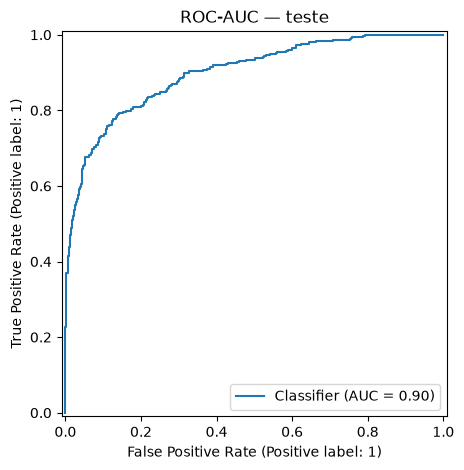

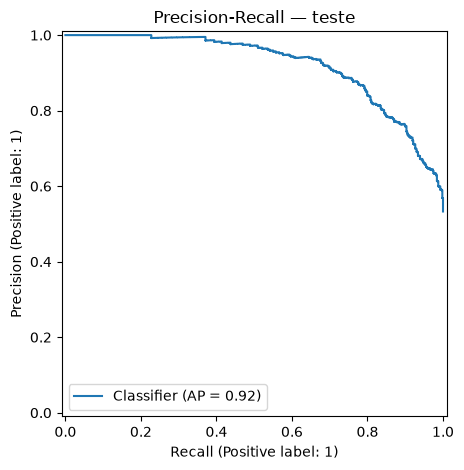

In [13]:

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Matriz de confusão — teste")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.tight_layout()
plt.savefig(FIGURES / "04_matriz_confusao.png", dpi=160, bbox_inches="tight")
plt.show()

RocCurveDisplay.from_predictions(y_test, proba)
plt.title("ROC-AUC — teste")
plt.tight_layout()
plt.savefig(FIGURES / "05_roc_auc.png", dpi=160, bbox_inches="tight")
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, proba)
plt.title("Precision-Recall — teste")
plt.tight_layout()
plt.savefig(FIGURES / "06_precision_recall.png", dpi=160, bbox_inches="tight")
plt.show()


## 12. Feature Importance e interpretação

A importância por permutação é calculada sobre o conjunto de teste. Isso mede o impacto das variáveis sem expor ao modelo os campos removidos por leakage.

,feature_original,importance_mean,importance_std
0,taxa_alfabetizacao,0.343163,0.014705
11,taxa_alfabetizacao_meta_base,0.107140,0.015376
1,media_portugues,0.008253,0.005365
7,proporcao_aluno_nivel_5,0.005510,0.001916
5,proporcao_aluno_nivel_3,0.002878,0.003240
6,proporcao_aluno_nivel_4,0.002535,0.002053
10,proporcao_aluno_nivel_8,0.002495,0.002406
8,proporcao_aluno_nivel_6,0.001877,0.001607
4,proporcao_aluno_nivel_2,0.000771,0.000404
9,proporcao_aluno_nivel_7,0.000357,0.001758


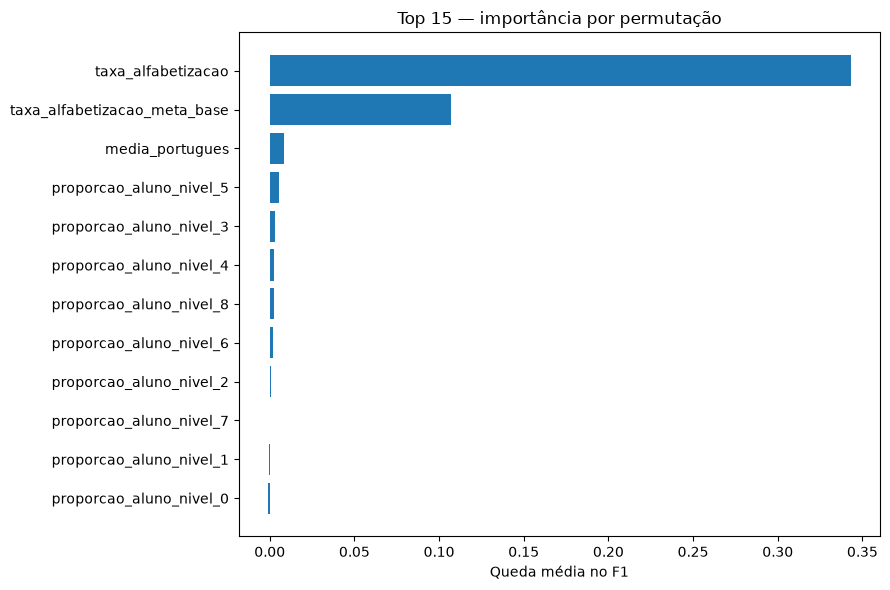

In [14]:
# ============================================================
# 12. Feature Importance e interpretação
# ============================================================
perm = permutation_importance(
    champion, X_test, y_test,
    n_repeats=5,
    random_state=SEED,
    scoring="f1",
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature_original": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(importance.head(20))
importance.to_csv(REPORTS / "feature_importance_permutation.csv", index=False)

top = importance.head(15).sort_values("importance_mean")
plt.figure(figsize=(9,6))
plt.barh(top["feature_original"], top["importance_mean"])
plt.title("Top 15 — importância por permutação")
plt.xlabel("Queda média no F1")
plt.tight_layout()
plt.savefig(FIGURES / "07_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()


## 13. SHAP

Quando a biblioteca `shap` estiver disponível, o notebook calcula explicabilidade para modelos de árvore. Caso contrário, a análise por permutação permanece como método principal de interpretação.

In [15]:
# ============================================================
# 13. SHAP
# ============================================================
shap_status = {"available": False}

try:
    import shap
    shap_status["available"] = True

    inner_model = champion.named_steps["model"]
    prep_fitted = champion.named_steps["prep"]
    Xt = prep_fitted.transform(X_test)

    if hasattr(inner_model, "feature_importances_"):
        feature_names = prep_fitted.get_feature_names_out()
        explainer = shap.TreeExplainer(inner_model)
        shap_values = explainer.shap_values(Xt)

        if isinstance(shap_values, list):
            vals = shap_values[-1]
        elif getattr(shap_values, "ndim", 0) == 3:
            vals = shap_values[:, :, -1]
        else:
            vals = shap_values

        mean_abs = np.abs(vals).mean(axis=0)
        shap_df = (
            pd.DataFrame({
                "feature": feature_names[:len(mean_abs)],
                "mean_abs_shap": mean_abs
            })
            .sort_values("mean_abs_shap", ascending=False)
        )

        display(shap_df.head(20))
        shap_df.to_csv(REPORTS / "shap_importance.csv", index=False)

        shap.summary_plot(
            vals,
            Xt,
            feature_names=feature_names[:vals.shape[1]],
            show=False,
            max_display=20
        )
        plt.tight_layout()
        plt.savefig(FIGURES / "08_shap_summary.png", dpi=160, bbox_inches="tight")
        plt.show()
    else:
        shap_status["motivo"] = "Modelo campeão não possui feature_importances_."

except Exception as exc:
    shap_status["erro"] = str(exc)

with open(REPORTS / "shap_status.json", "w", encoding="utf-8") as f:
    json.dump(shap_status, f, ensure_ascii=False, indent=2)

print(shap_status)


{'available': True, 'motivo': 'Modelo campeão não possui feature_importances_.'}


## 14. Ranking de risco municipal

A saída operacional transforma a probabilidade do modelo em uma fila de priorização. Quanto menor a probabilidade de atingir a meta, maior a prioridade potencial para investigação/intervenção.

### Ordem de execução

A célula seguinte **cria** o objeto `risk`. A etapa de municípios/UF usa esse objeto depois. Execute as células em ordem a partir da avaliação do modelo.

In [16]:
# ============================================================
# 14. Ranking de risco municipal
# ============================================================
# Este bloco cria `risk` antes de qualquer agregação territorial.
# É autocontido e pode ser executado independentemente da numeração visual.
if "X_test" not in globals() or "y_test" not in globals() or "proba" not in globals() or "pred" not in globals():
    raise NameError(
        "Objetos de avaliação não encontrados. Execute primeiro as etapas "
        "de separação treino/teste e avaliação do modelo."
    )

risk = X_test.copy()
risk["target_real"] = np.asarray(y_test)
risk["probabilidade_atingir_meta"] = np.asarray(proba)
risk["probabilidade_nao_atingir_meta"] = 1 - risk["probabilidade_atingir_meta"]
risk["predicao"] = np.asarray(pred)

# Anexa somente contexto territorial disponível na mesma linha de X_test.
context_cols = []
for c in [municipality_col, uf_col, year_col]:
    if c and c in work.columns and c not in context_cols:
        context_cols.append(c)

if context_cols:
    context_test = work.loc[X_test.index, context_cols].copy()
    context_test = context_test.loc[:, ~context_test.columns.duplicated()]

    # Evita duplicar uma coluna que já exista em X_test.
    context_test = context_test.drop(
        columns=[c for c in context_test.columns if c in risk.columns],
        errors="ignore"
    )

    risk = pd.concat([context_test, risk], axis=1)

# Segurança contra duplicidades de nomes.
risk = risk.loc[:, ~risk.columns.duplicated()].copy()

risk["nivel_risco"] = pd.cut(
    risk["probabilidade_nao_atingir_meta"],
    bins=[-np.inf, 0.33, 0.66, np.inf],
    labels=["baixo", "medio", "alto"]
)

risk = risk.sort_values(
    "probabilidade_nao_atingir_meta",
    ascending=False
)

display(risk.head(30))
risk.to_csv(REPORTS / "ranking_risco_municipal.csv", index=False)

print("Ranking criado com sucesso.")
print("Dimensão:", risk.shape)
print("Colunas duplicadas:", risk.columns[risk.columns.duplicated()].tolist())


,id_municipio,ano,taxa_alfabetizacao,media_portugues,proporcao_aluno_nivel_0,proporcao_aluno_nivel_1,proporcao_aluno_nivel_2,proporcao_aluno_nivel_3,proporcao_aluno_nivel_4,proporcao_aluno_nivel_5,proporcao_aluno_nivel_6,proporcao_aluno_nivel_7,proporcao_aluno_nivel_8,taxa_alfabetizacao_meta_base,target_real,probabilidade_atingir_meta,probabilidade_nao_atingir_meta,predicao,nivel_risco
11680,4320453,2024,11.100000,712.169400,5.560000,0.000000,27.780000,33.330000,22.220000,11.110000,0.000000,0.000000,0.000000,85.40,0,4.758943e-08,1.000000,0,alto
15694,4302584,2024,27.300000,727.093700,4.540000,9.090000,13.640000,22.730000,22.730000,13.640000,4.550000,4.550000,4.550000,100.00,0,5.195949e-07,0.999999,0,alto
15682,1713601,2024,19.710000,718.700000,7.960000,4.850000,21.830000,23.870000,26.440000,1.490000,6.030000,4.540000,2.980000,70.00,0,8.057226e-06,0.999992,0,alto
13615,2109056,2024,34.420000,734.790000,2.210000,0.000000,13.260000,18.840000,35.470000,20.000000,8.000000,2.210000,0.000000,73.80,0,5.952457e-05,0.999940,0,alto
15461,4301875,2024,27.166667,721.974733,2.446667,9.893333,16.066667,28.343333,18.510000,14.846667,7.450000,2.446667,0.000000,61.00,0,2.709995e-04,0.999729,0,alto
18573,4320321,2024,50.000000,750.051800,0.000000,0.000000,0.000000,20.830000,29.170000,33.330000,8.330000,8.330000,0.000000,84.00,0,5.446113e-04,0.999455,0,alto
11866,4310413,2024,35.300000,721.484000,0.000000,0.000000,47.060000,17.650000,5.880000,17.650000,11.760000,0.000000,0.000000,62.70,0,7.463229e-04,0.999254,0,alto
14430,2926905,2024,15.620000,715.440000,0.000000,18.750000,18.750000,18.750000,31.250000,6.250000,3.120000,3.120000,0.000000,36.50,0,8.207483e-04,0.999179,0,alto
15243,4313490,2024,36.733333,739.104933,0.000000,4.700000,15.063333,13.540000,34.826667,6.790000,18.853333,6.223333,0.000000,62.10,0,1.008261e-03,0.998992,0,alto
12984,2411502,2024,35.930000,726.790000,3.990000,11.096667,9.353333,25.903333,19.943333,16.760000,9.443333,2.863333,0.643333,66.50,0,1.202427e-03,0.998798,0,alto


Ranking criado com sucesso.
Dimensão: (1047, 19)
Colunas duplicadas: []


## 15. Municípios e regiões prioritárias

In [17]:
# ============================================================
# 15. Municípios e regiões prioritárias
# ============================================================
# Validação de unicidade das colunas antes das agregações.
duplicated_names = pd.Index(risk.columns)[pd.Index(risk.columns).duplicated()].tolist()
assert len(duplicated_names) == 0, (
    f"Existem colunas duplicadas no ranking: {duplicated_names}"
)
print("Validação OK: todas as colunas do ranking possuem nomes únicos.")


Validação OK: todas as colunas do ranking possuem nomes únicos.


In [18]:
# Antes dos agrupamentos, garantir que nenhum nome de coluna apareça duas vezes.
risk = risk.loc[:, ~risk.columns.duplicated()].copy()

# A chave municipal deve existir como uma única coluna.
municipality_key = municipality_col if municipality_col in risk.columns else None

if municipality_key:
    municipal_summary = (
        risk.groupby(municipality_key, dropna=False, sort=False)
        .agg(
            observacoes=("probabilidade_nao_atingir_meta", "size"),
            risco_medio=("probabilidade_nao_atingir_meta", "mean"),
            risco_p90=("probabilidade_nao_atingir_meta", lambda s: s.quantile(.90)),
        )
        .sort_values("risco_medio", ascending=False)
    )

    display(municipal_summary.head(20))
    municipal_summary.to_csv(REPORTS / "municipios_prioritarios.csv")
else:
    print("Não foi possível identificar uma chave municipal para o ranking.")

group_col = uf_col if uf_col and uf_col in risk.columns else None

if group_col:
    regional = (
        risk.groupby(group_col, dropna=False, sort=False)
        .agg(
            observacoes=("probabilidade_nao_atingir_meta", "size"),
            risco_medio=("probabilidade_nao_atingir_meta", "mean"),
            proporcao_alto=("nivel_risco", lambda s: (s.astype(str) == "alto").mean())
        )
        .sort_values("risco_medio", ascending=False)
    )

    display(regional)

    regional.to_csv(REPORTS / "risco_por_uf.csv")

    top = regional.head(15).sort_values("risco_medio")
    plt.figure(figsize=(9,5))
    plt.barh(top.index.astype(str), top["risco_medio"])
    plt.title("Risco médio de não atingimento por UF")
    plt.xlabel("Probabilidade média de não atingir a meta")
    plt.tight_layout()
    plt.savefig(FIGURES / "09_risco_por_uf.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("Não foi identificada uma chave de UF para a análise regional.")


,observacoes,risco_medio,risco_p90
id_municipio,,,
4320453,1,1.000000,1.000000
4302584,1,0.999999,0.999999
1713601,1,0.999992,0.999992
2109056,1,0.999940,0.999940
4301875,1,0.999729,0.999729
4320321,1,0.999455,0.999455
4310413,1,0.999254,0.999254
2926905,1,0.999179,0.999179
4313490,1,0.998992,0.998992


Não foi identificada uma chave de UF para a análise regional.


In [19]:
# Garante que `risk` exista mesmo quando esta célula é executada isoladamente.
if "risk" not in globals():
    raise NameError(
        "A variável `risk` ainda não existe. Execute a célula '14. Ranking de risco municipal' "
        "antes desta etapa."
    )

risk = risk.loc[:, ~risk.columns.duplicated()].copy()

municipality_key = (
    municipality_col
    if municipality_col and municipality_col in risk.columns
    else None
)

if municipality_key:
    municipal_summary = (
        risk.groupby(municipality_key, dropna=False, sort=False)
        .agg(
            observacoes=("probabilidade_nao_atingir_meta", "size"),
            risco_medio=("probabilidade_nao_atingir_meta", "mean"),
            risco_p90=("probabilidade_nao_atingir_meta", lambda s: s.quantile(.90)),
        )
        .sort_values("risco_medio", ascending=False)
    )

    display(municipal_summary.head(20))
    municipal_summary.to_csv(REPORTS / "municipios_prioritarios.csv")
else:
    print("Não foi possível identificar uma chave municipal para o ranking.")

group_col = uf_col if uf_col and uf_col in risk.columns else None

if group_col:
    regional = (
        risk.groupby(group_col, dropna=False, sort=False)
        .agg(
            observacoes=("probabilidade_nao_atingir_meta", "size"),
            risco_medio=("probabilidade_nao_atingir_meta", "mean"),
            proporcao_alto=(
                "nivel_risco",
                lambda s: (s.astype(str) == "alto").mean()
            )
        )
        .sort_values("risco_medio", ascending=False)
    )

    display(regional)
    regional.to_csv(REPORTS / "risco_por_uf.csv")

    top = regional.head(15).sort_values("risco_medio")
    if not top.empty:
        plt.figure(figsize=(9,5))
        plt.barh(top.index.astype(str), top["risco_medio"])
        plt.title("Risco médio de não atingimento por UF")
        plt.xlabel("Probabilidade média de não atingir a meta")
        plt.tight_layout()
        plt.savefig(FIGURES / "09_risco_por_uf.png", dpi=160, bbox_inches="tight")
        plt.show()
else:
    print("Não foi identificada uma chave de UF para a análise regional.")


,observacoes,risco_medio,risco_p90
id_municipio,,,
4320453,1,1.000000,1.000000
4302584,1,0.999999,0.999999
1713601,1,0.999992,0.999992
2109056,1,0.999940,0.999940
4301875,1,0.999729,0.999729
4320321,1,0.999455,0.999455
4310413,1,0.999254,0.999254
2926905,1,0.999179,0.999179
4313490,1,0.998992,0.998992


Não foi identificada uma chave de UF para a análise regional.


,municipios
cluster,
0,1670
1,1235
2,288
3,2039


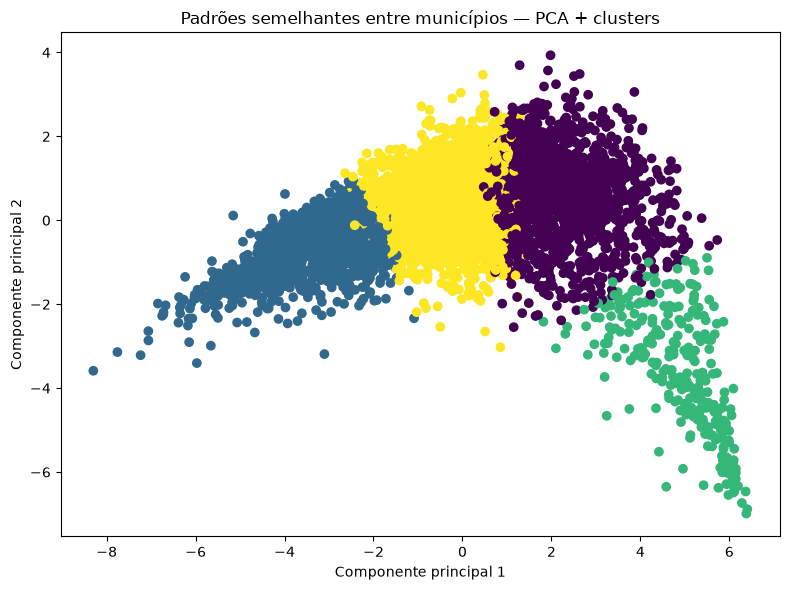

In [20]:
if municipality_col and municipality_col in work.columns:
    numeric_candidates = [
        c for c in work.select_dtypes(include=np.number).columns
        if c != TARGET and c not in drop_cols
    ]

    if len(numeric_candidates) >= 2:
        agg = (
            work.groupby(municipality_col)[numeric_candidates]
            .mean(numeric_only=True)
            .dropna(axis=1, how="all")
            .dropna()
        )

        if len(agg) >= 10 and agg.shape[1] >= 2:
            z = StandardScaler().fit_transform(agg)
            k = min(4, max(2, len(agg)//20))
            km = KMeans(n_clusters=k, random_state=SEED, n_init=20)
            clusters = km.fit_predict(z)

            cluster_df = agg.copy()
            cluster_df["cluster"] = clusters

            display(cluster_df.groupby("cluster").size().rename("municipios").to_frame())
            cluster_df.to_csv(REPORTS / "clusters_municipais.csv")

            pca = PCA(n_components=2, random_state=SEED)
            coords = pca.fit_transform(z)

            plt.figure(figsize=(8,6))
            plt.scatter(coords[:,0], coords[:,1], c=clusters)
            plt.title("Padrões semelhantes entre municípios — PCA + clusters")
            plt.xlabel("Componente principal 1")
            plt.ylabel("Componente principal 2")
            plt.tight_layout()
            plt.savefig(FIGURES / "10_clusters_municipais.png", dpi=160, bbox_inches="tight")
            plt.show()
        else:
            print("Dados insuficientes para clustering territorial.")
    else:
        print("Menos de duas variáveis numéricas disponíveis para clustering.")
else:
    print("Não foi identificada uma chave municipal.")



## 17. Síntese executiva

### O que o modelo entrega

A solução transforma a Gold em uma ferramenta de priorização:

- **classificação:** probabilidade de atingir a meta;
- **risco:** probabilidade de não atingir;
- **ranking:** municípios prioritários;
- **interpretação:** variáveis mais influentes;
- **território:** comparação entre UFs/regiões;
- **padrões:** agrupamento de municípios semelhantes;
- **temporalidade:** quando há histórico, previsão do próximo período.

### Interpretação para política pública

A probabilidade predita não deve ser interpretada como causalidade. Ela funciona como um **sinal de priorização**. Municípios com alto risco podem ser direcionados para investigação de contexto, acompanhamento de indicadores e desenho de ações específicas.

### Limitação de granularidade

A Gold disponível é agregada. Portanto, este notebook não afirma prever o resultado individual de cada aluno. Para uma implementação estritamente aluno-a-aluno, seria necessário incorporar uma base de avaliação com registros individuais e relacioná-la à Gold por chaves territoriais/escolares, mantendo a Gold como fonte de contexto.

Essa limitação é metodologicamente preferível a fabricar observações individuais a partir de taxas municipais.


## 18. Persistência dos artefatos finais

In [21]:
# ============================================================
# 18. Persistência dos artefatos finais
# ============================================================
# Esta célula não depende de `DATA_FILE`, que pode não existir quando
# o notebook for executado em células individuais.
if "champion" not in globals():
    raise NameError(
        "O modelo campeão não está disponível. Execute as etapas de treinamento e avaliação."
    )

if "metrics_final" not in globals():
    raise NameError(
        "As métricas finais não estão disponíveis. Execute a etapa de avaliação."
    )

dump(champion, MODELS / "champion_model.joblib")

# Recupera a fonte da forma mais robusta possível.
source_file = None

if "base_path" in globals():
    source_file = str(base_path)
elif "DATA_FILE" in globals():
    source_file = str(DATA_FILE)
elif "inventory_df" in globals() and len(inventory_df) > 0:
    source_file = str(inventory_df.iloc[0]["arquivo"])
else:
    source_file = "data/gold/arquivos utilizados no notebook"

metadata = {
    "fonte": source_file,
    "target": str(TARGET),
    "estrategia_temporal": bool(use_future_target),
    "split_temporal": bool(temporal_split),
    "modelo": str(best_name),
    "metricas_teste": {
        k: float(v) for k, v in metrics_final.items()
    },
    "colunas_removidas": sorted([str(c) for c in drop_cols]),
    "features_numericas": [str(c) for c in numeric_features],
    "features_categoricas": [str(c) for c in categorical_features],
    "unidade_observacional": "municipio/ano",
    "limitacao_granularidade": (
        "A Gold disponível é agregada. Não foi fabricado target individual."
    )
}

with open(MODELS / "champion_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

summary = {
    "base": source_file,
    "linhas": int(len(work)),
    "colunas": int(len(work.columns)),
    "target": str(TARGET),
    "unidade_observacional": "municipio/ano",
    "modelo": str(best_name),
    "metricas": {
        k: round(float(v), 4) for k, v in metrics_final.items()
    },
    "principais_features": (
        importance.head(10)["feature_original"].astype(str).tolist()
        if "importance" in globals() else []
    ),
    "arquivos_gerados": [
        "reports/model_comparison_cv.csv",
        "reports/metrics_final.json",
        "reports/feature_importance_permutation.csv",
        "reports/ranking_risco_municipal.csv",
        "reports/municipios_prioritarios.csv",
        "reports/risco_por_uf.csv",
        "models/champion_model.joblib",
        "models/champion_model_metadata.json",
    ]
}

with open(REPORTS / "executive_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Artefatos finais salvos:")
print(" -", MODELS / "champion_model.joblib")
print(" -", MODELS / "champion_model_metadata.json")
print(" -", REPORTS / "executive_summary.json")
print("\nResumo:")
print(json.dumps(summary, ensure_ascii=False, indent=2))


Artefatos finais salvos:
 - f:\FIAP\TechChallenge-Fase3\models\champion_model.joblib
 - f:\FIAP\TechChallenge-Fase3\models\champion_model_metadata.json
 - f:\FIAP\TechChallenge-Fase3\reports\executive_summary.json

Resumo:
{
  "base": "f:\\FIAP\\TechChallenge-Fase3\\data\\gold\\gold_dataset_ia_municipio.parquet",
  "linhas": 5232,
  "colunas": 29,
  "target": "target_atingiu_meta",
  "unidade_observacional": "municipio/ano",
  "modelo": "logistic_regression",
  "metricas": {
    "accuracy": 0.8099,
    "balanced_accuracy": 0.8083,
    "precision": 0.8144,
    "recall": 0.8333,
    "f1": 0.8237,
    "roc_auc": 0.8987,
    "pr_auc": 0.9205
  },
  "principais_features": [
    "taxa_alfabetizacao",
    "taxa_alfabetizacao_meta_base",
    "media_portugues",
    "proporcao_aluno_nivel_5",
    "proporcao_aluno_nivel_3",
    "proporcao_aluno_nivel_4",
    "proporcao_aluno_nivel_8",
    "proporcao_aluno_nivel_6",
    "proporcao_aluno_nivel_2",
    "proporcao_aluno_nivel_7"
  ],
  "arquivos_gera

In [22]:
# Validação final de proveniência
assert "source_file" in globals()
assert "TARGET" in globals()
assert "champion" in globals()
assert (MODELS / "champion_model.joblib").exists()
assert (MODELS / "champion_model_metadata.json").exists()
assert (REPORTS / "executive_summary.json").exists()

print("Validação final concluída com sucesso.")


Validação final concluída com sucesso.



## 19. Checklist de entrega

### Dados e entendimento
- [x] Camada Gold utilizada como fonte principal.
- [x] Auditoria de schema, missing e cardinalidade.
- [x] EDA com distribuições e associações.
- [x] Hipóteses e limitações documentadas.

### Machine Learning
- [x] Target definido sem fabricação de registros.
- [x] Prevenção de data leakage.
- [x] Imputação numérica.
- [x] Transformação/escala numérica.
- [x] Encoding categórico.
- [x] Pré-processamento integrado ao pipeline.
- [x] Baseline.
- [x] Comparação de algoritmos.
- [x] Validação cruzada.
- [x] Otimização do modelo.
- [x] Avaliação em teste.
- [x] Feature Importance.
- [x] SHAP quando disponível.

### Inteligência aplicada
- [x] Ranking de risco municipal.
- [x] Análise territorial.
- [x] Clustering de padrões semelhantes.
- [x] Perspectiva temporal quando suportada pela Gold.
- [x] Aplicação para priorização de políticas públicas.

### Limitação explicitamente registrada
A Gold atual não permite identificar o resultado individual de cada aluno. O notebook não inventa esse dado. A previsão executada é municipal/temporal, derivada diretamente da granularidade disponível na Gold.
